<h1 align="center">
    THIS NOTEBOOK IS A PERSONAL REWORK OF THE Qiskit Machine Learning TUTORIAL
    <a href="https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02a_training_a_quantum_model_on_a_real_dataset.html">
        Training a Quantum Model on a Real Dataset
    </a>
</h1>

Here we train a quantum machine learning model on a a real-life classical dataset to tackle a classification task. The dataset considered is the Iris flower dataset, available in scikit-learn. For comparison, we’ll first train a classical counterpart to the quantum model.

**General workflow:**

1. Load the dataset and explore what it looks like.

2. Train a classical model using SVC from scikit-learn to see how well the classification problem can be solved using classical methods.

3. Introduce the Variational Quantum Classifier (VQC).

4. Compare the results obtained from both models

In [1]:
import pandas as pd
import seaborn as sns
import time

from matplotlib import pyplot as plt
from IPython.display import clear_output

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC

from qiskit.primitives import StatevectorSampler as Exact_Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

from qiskit.circuit.library import zz_feature_map, real_amplitudes, efficient_su2

# Data loading, analysis, and manipulation

The Iris dataset consists of 150 datapoints, 4 features, and 3 classes. The dataset is perfectly balanced, as there are the same number of samples (50) in each class. Features are not normalized and their value ranges are different; so, transforming the features to the same scale may be helpful. This step is done using **_scikit-learn_**. The dataset is loaded as a dictionary-like object with the followying keys:
- data
- target
- feature_names
- target_names
- DESCR
- filename
- ...

We then plot the features pair-wise to see if there’s an observable correlation between them. This is done with **_seaborn_**. Seaborn works well with **_pandas_** dataframes, so we first need to build the dataframe starting from the sklearn object. Pandas dataframes are created with the constructor

pd.DataFrame(data=None, index=None, columns=None, dtype=None, copy=None),

where:
- data: it's the real content. It can be a numpy array, a dictionary, a list of lists, etc.
- columns: these are the columns names.
- index: the rows names. Default ones are numbers starting from 0

**Important**: in this notebook, Pandas is used only for the graphical reason. If you are not interest in the data visualization, Pandas can be avoided. All the data manipulation is performed with Scikit-Learn

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

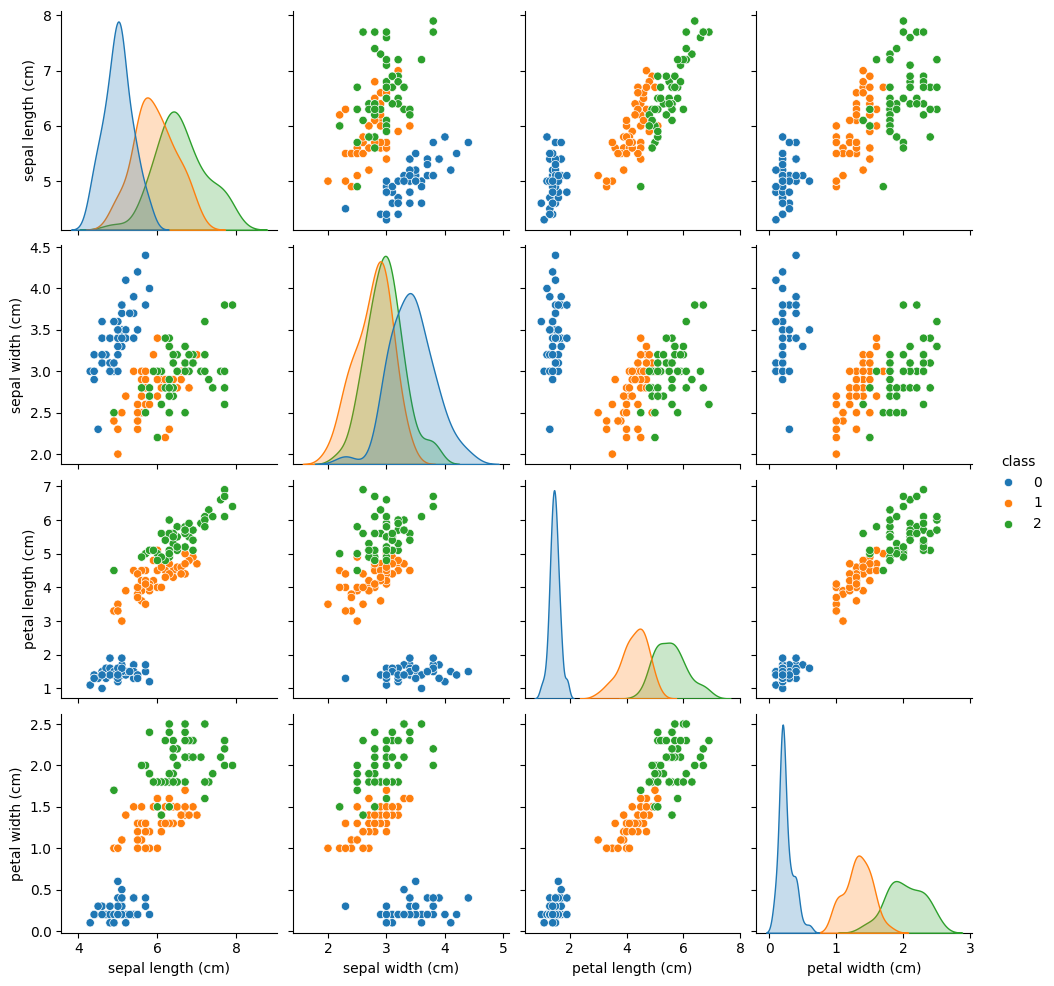

In [2]:
##################################################################################################
# Load dataset, extract features and labels, normalize features, and print information
iris = load_iris()   # load dataset: return a dictionary-like object
features = iris.data   # extract features as a numpy (num datapoints x num features) array 
labels = iris.target   # extract labels as a numpy (num features x 1) array
features_names = iris.feature_names   # extract features names as a (num features-long) list
normalized_features = MinMaxScaler().fit_transform(features)   # re-scale features to the [0,1] range

print(iris.DESCR)   # print information

##################################################################################################
# Plot features pair-wise to look for correlations
df = pd.DataFrame(data = features, columns = features_names)   # create a Pandas DataFrame. Columns are named after the features
df["class"] = labels   # add the "class" column with target values
sns.pairplot(df, hue = "class", palette = "tab10")   # a matrix of graphs, comparing each df column with all the others and coloring datapoints according to their class

##################################################################################################
# Split the dataset into a training part and a a test part
algorithm_globals.random_seed = 123   # fix the seed to ensure the results are reproducible.
train_features, test_features, train_labels, test_labels = train_test_split(
    normalized_features,
    labels,
    train_size = 0.8,
    random_state = algorithm_globals.random_seed
)

From the plots, we see that class 0 is easily separable from the other two classes, while classes 1 and 2 are sometimes intertwined, especially regarding the “sepal width” feature.

#  Training a Classical Machine Learning Model

We now split the dataset into a train and a test parts using scikit-learn. We then train a classical Support Vector Classifier from scikit-learn, using the default parameters. Finally, we check the classical model performance

In [3]:
##################################################################################################
# Train a classical Support Vector Classifier from scikit-learn
svc = SVC()
_ = svc.fit(train_features, train_labels)  # suppress printing the return value

train_score_c4 = svc.score(train_features, train_labels)
test_score_c4 = svc.score(test_features, test_labels)

print(f"Classical SVC on the training dataset: {train_score_c4:.2f}")
print(f"Classical SVC on the test dataset:     {test_score_c4:.2f}")

Classical SVC on the training dataset: 0.99
Classical SVC on the test dataset:     0.97


# Training a Quantum Machine Learning Model

We’ll train a variational quantum classifier (VQC), the simplest classifier available in Qiskit Machine Learning.

**Feature map**: ZZ feature map, defined as

zz_feature_map(feature_dimension, reps=2, entanglement='full', alpha=2.0, data_map_func=None, parameter_prefix='x', insert_barriers=False, name='ZZFeatureMap').

We pass num_features as feature_dimension ---> 4 qubits

**Ansatz**: real_amplitudes, defined as

real_amplitudes(num_qubits, entanglement='reverse_linear', reps=3, skip_unentangled_qubits=False, skip_final_rotation_layer=False, parameter_prefix='θ', insert_barriers=False, name='RealAmplitudes')

**Optimizer**: COBYLA (gradient free optimizer)

**Backend**: we employ StatevectorSimulator

We recall that the class VQC is implemented as:

VQC(num_qubits=None, feature_map=None, ansatz=None, loss='cross_entropy', optimizer=None, warm_start=False, initial_point=None, callback=None, *, sampler=None, interpret=None, output_shape=None, pass_manager=None)

Feature map: number of encoded parameters (features loaded): 4. Circuit:


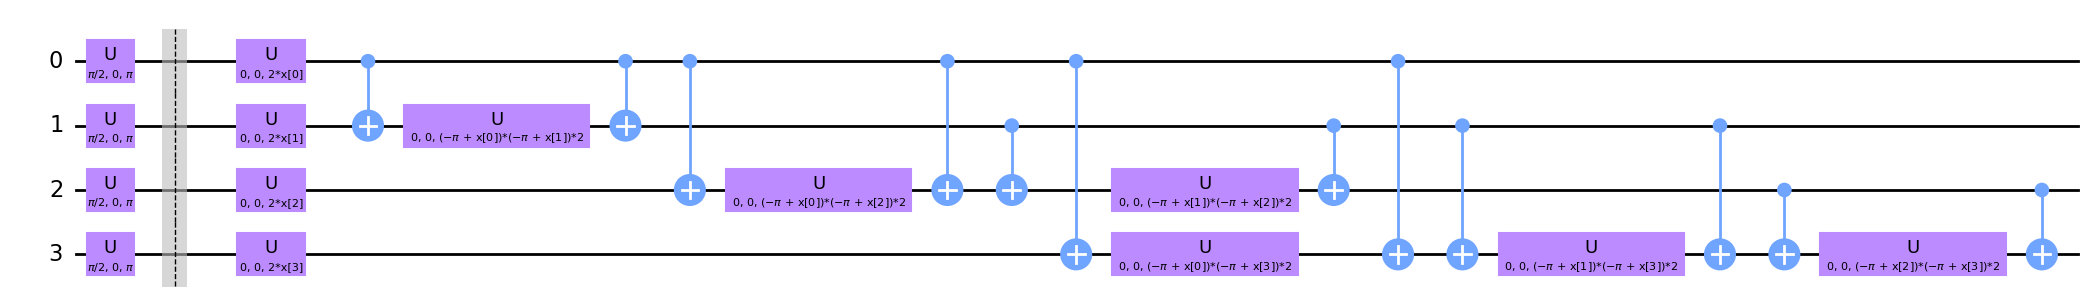

Ansatz: number of encoded parameters (trainable weights): 16. Circuit:


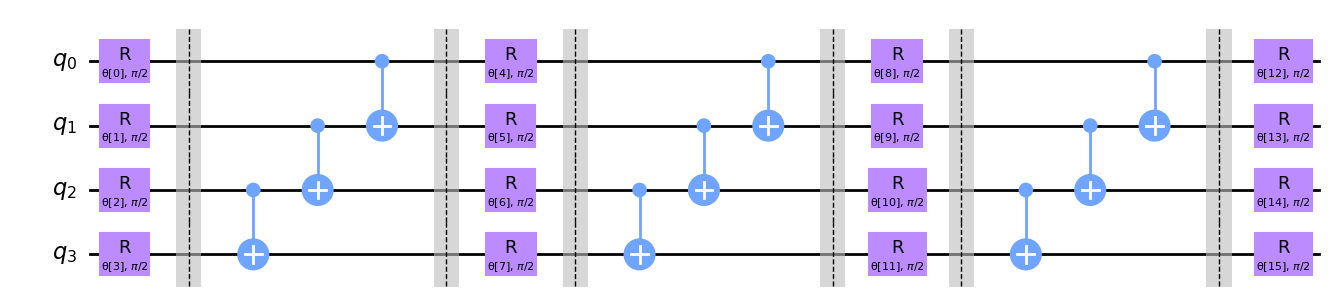

In [4]:
##################################################################################################
# Create the quantum circuit
num_features =  features.shape[1]

feature_map = zz_feature_map(feature_dimension = num_features, reps = 1, insert_barriers = True)   # feature map circuit
print(f"Feature map: number of encoded parameters (features loaded): {feature_map.num_parameters}. Circuit:")
display(feature_map.decompose().draw(output = "mpl", style = "clifford", fold = 50))

ansatz = real_amplitudes(num_qubits = num_features, reps = 3, insert_barriers = True)   # ansatz circuit
print(f"Ansatz: number of encoded parameters (trainable weights): {ansatz.num_parameters}. Circuit:")
display(ansatz.decompose().draw(output = "mpl", style = "clifford", fold = 50))

##################################################################################################
# Define the chosen primitive. VQC requires a Sampler primitive, and we employ StatevectorSimulator as sampler
statevector_sampler = Exact_Sampler()

##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()

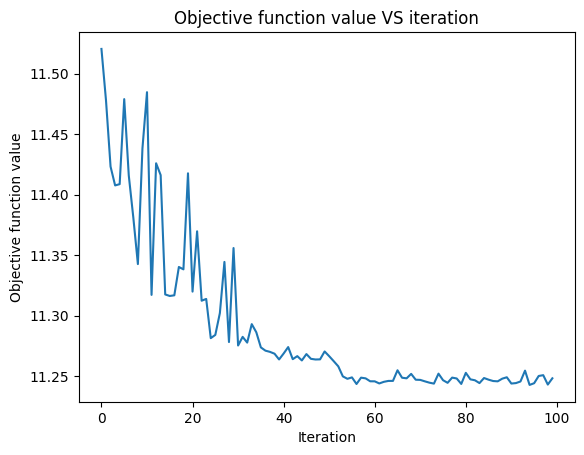

Training time: 89 seconds
Quantum VQC on the training dataset: 0.60
Quantum VQC on the test dataset:     0.63


In [5]:
##################################################################################################
# Construct the variational quantum classifier
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
vqc = VQC(
    # elements part of the neural network
    feature_map = feature_map,
    ansatz = ansatz,
    sampler = statevector_sampler,
    # elements part of the classifier
    loss = "cross_entropy",
    optimizer = COBYLA(maxiter = 100),
    callback = callback_graph,
    pass_manager = None
)

##################################################################################################
# Train the model : fit the classifier with the data
start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

##################################################################################################
# Evaluate the classifier performance
train_score_q4 = vqc.score(train_features, train_labels)
test_score_q4 = vqc.score(test_features, test_labels)
print(f"Quantum VQC on the training dataset: {train_score_q4:.2f}")
print(f"Quantum VQC on the test dataset:     {test_score_q4:.2f}")

# Reducing the Number of Features

In this section, we reduce the number of features in our dataset and train our models again. We do so by applying a Principal Component Analysis (PCA) transformation. In this example, we transform our four features into two features only. This dimensionality reduction is for educational purposes only. The steps are the same as before, except for the first one where we apply the PCA

### Data loading, manipulation, and PCA

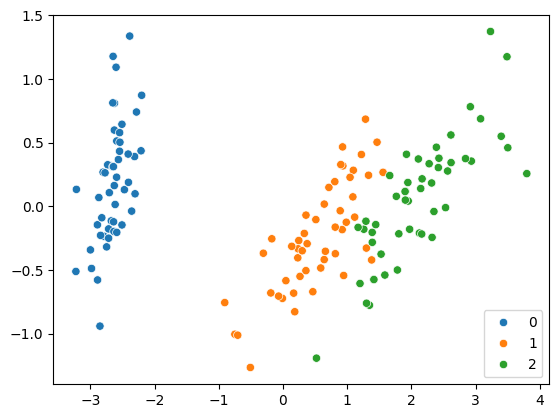

In [6]:
##################################################################################################
# Load dataset, extract features and labels, normalize features, and print information
iris = load_iris()   # load dataset: return a dictionary-like object
features = iris.data   # extract features as a numpy (num datapoints x num features) array 
labels = iris.target   # extract labels as a numpy (num features x 1) array
features_names = iris.feature_names   # extract features names as a (num features-long) list

features = PCA(n_components = 2).fit_transform(features)   # apply PCA
normalized_features = MinMaxScaler().fit_transform(features)   # re-scale features to the [0,1] range

##################################################################################################
# Plot the two features to look for correlations
sns.scatterplot(x = features[:, 0], y = features[:, 1], hue = labels, palette="tab10")

##################################################################################################
# Split the dataset into a training part and a a test part
algorithm_globals.random_seed = 123   # fix the seed to ensure the results are reproducible.
train_features, test_features, train_labels, test_labels = train_test_split(
    normalized_features,
    labels,
    train_size = 0.8,
    random_state = algorithm_globals.random_seed
)

### Train a classical ML model

In [7]:
##################################################################################################
# Train a classical Support Vector Classifier from scikit-learn
svc = SVC()
_ = svc.fit(train_features, train_labels)  # suppress printing the return value

train_score_c2 = svc.score(train_features, train_labels)
test_score_c2 = svc.score(test_features, test_labels)

print(f"Classical SVC on the training dataset: {train_score_c2:.2f}")
print(f"Classical SVC on the test dataset:     {test_score_c2:.2f}")

Classical SVC on the training dataset: 0.99
Classical SVC on the test dataset:     0.93


### Train a quantum ML model

Feature map: number of encoded parameters (features loaded): 2. Circuit:


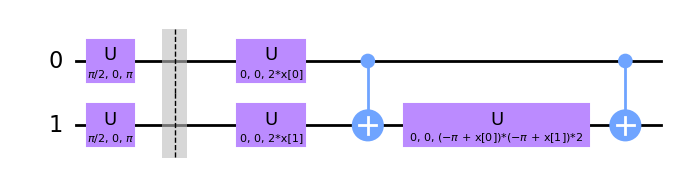

Ansatz: number of encoded parameters (trainable weights): 8. Circuit:


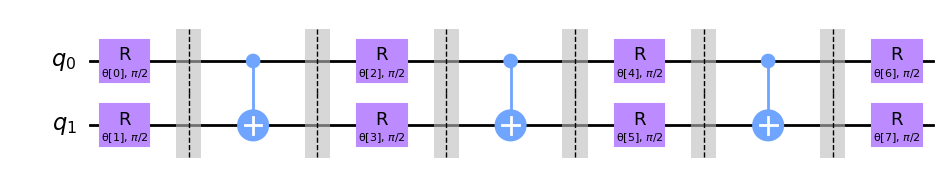

In [8]:
##################################################################################################
# Create the quantum circuit
num_features =  features.shape[1]

feature_map = zz_feature_map(feature_dimension = num_features, reps = 1, insert_barriers = True)   # feature map circuit
print(f"Feature map: number of encoded parameters (features loaded): {feature_map.num_parameters}. Circuit:")
display(feature_map.decompose().draw(output = "mpl", style = "clifford", fold = 50))

ansatz = real_amplitudes(num_qubits = num_features, reps = 3, insert_barriers = True)   # ansatz circuit
print(f"Ansatz: number of encoded parameters (trainable weights): {ansatz.num_parameters}. Circuit:")
display(ansatz.decompose().draw(output = "mpl", style = "clifford", fold = 50))

##################################################################################################
# Define the chosen primitive. VQC requires a Sampler primitive, and we employ StatevectorSimulator as sampler
statevector_sampler = Exact_Sampler()

##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()

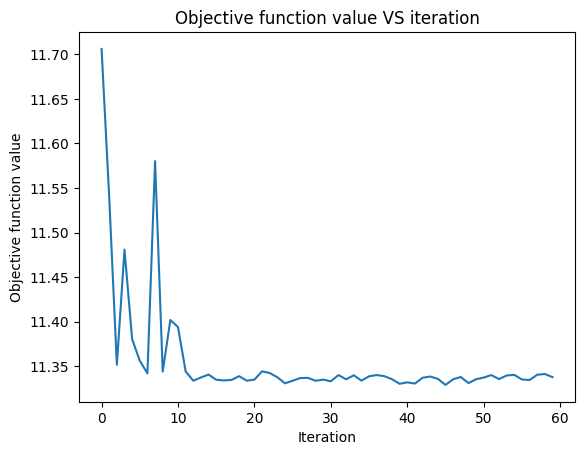

Training time: 40 seconds
Quantum VQC on the training dataset using real_amplitudes: 0.50
Quantum VQC on the test dataset using real_amplitudes:     0.47


In [10]:
##################################################################################################
# Construct the variational quantum classifier
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
vqc = VQC(
    # elements part of the neural network
    feature_map = feature_map,
    ansatz = ansatz,
    sampler = statevector_sampler,
    # elements part of the classifier
    loss = "cross_entropy",
    optimizer = COBYLA(maxiter = 60),   # less iterations than before since it should converge faster with less qubits
    callback = callback_graph,
    pass_manager = None
)

##################################################################################################
# Train the model : fit the classifier with the data
start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

##################################################################################################
# Evaluate the classifier performance
train_score_q2_ra = vqc.score(train_features, train_labels)
test_score_q2_ra = vqc.score(test_features, test_labels)
print(f"Quantum VQC on the training dataset using real_amplitudes: {train_score_q2_ra:.2f}")
print(f"Quantum VQC on the test dataset using real_amplitudes:     {test_score_q2_ra:.2f}")

We now try to change ansatz

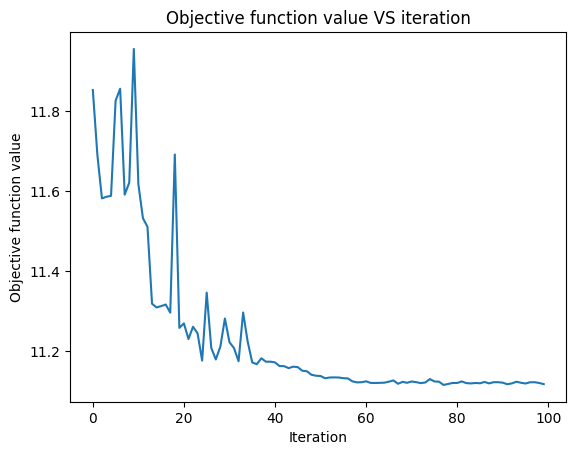

Training time: 71 seconds
Quantum VQC on the training dataset using efficient_su2: 0.62
Quantum VQC on the test dataset using efficient_su2:     0.60


In [11]:
ansatz = efficient_su2(num_qubits=num_features, reps=3)

##################################################################################################
# Construct the variational quantum classifier
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
vqc = VQC(
    # elements part of the neural network
    feature_map = feature_map,
    ansatz = ansatz,
    sampler = statevector_sampler,
    # elements part of the classifier
    loss = "cross_entropy",
    optimizer = COBYLA(maxiter = 60),
    callback = callback_graph,
    pass_manager = None
)

##################################################################################################
# Train the model : fit the classifier with the data
start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

##################################################################################################
# Evaluate the classifier performance
train_score_q2_eff = vqc.score(train_features, train_labels)
test_score_q2_eff = vqc.score(test_features, test_labels)

print(f"Quantum VQC on the training dataset using efficient_su2: {train_score_q2_eff:.2f}")
print(f"Quantum VQC on the test dataset using efficient_su2:     {test_score_q2_eff:.2f}")

# Conclusion

In [12]:
print(f"Model                            | Test Score | Train Score")
print(f"SVC, 4 features                  | {train_score_c4:10.2f} | {test_score_c4:10.2f}")
print(f"VQC, 4 features, real_amplitudes | {train_score_q4:10.2f} | {test_score_q4:10.2f}")
print(f"-----------------------------------------------------------")
print(f"SVC, 2 features                  | {train_score_c2:10.2f} | {test_score_c2:10.2f}")
print(f"VQC, 2 features, real_amplitudes | {train_score_q2_ra:10.2f} | {test_score_q2_ra:10.2f}")
print(f"VQC, 2 features, efficient_su2   | {train_score_q2_eff:10.2f} | {test_score_q2_eff:10.2f}")

Model                            | Test Score | Train Score
SVC, 4 features                  |       0.99 |       0.97
VQC, 4 features, real_amplitudes |       0.60 |       0.63
-----------------------------------------------------------
SVC, 2 features                  |       0.99 |       0.93
VQC, 2 features, real_amplitudes |       0.50 |       0.47
VQC, 2 features, efficient_su2   |       0.62 |       0.60
